<a href="https://colab.research.google.com/github/Noorumms/Canny-Edge-Detection-From-Scratch/blob/main/Canny_edge_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
def DisplayImage(images, main_title='Canny Edge Detection'):

    n = len(images)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    fig.suptitle(main_title, fontsize=16, fontweight='bold')

    axes = np.array(axes).flatten() if n > 1 else [axes]

    for ax, (title, img) in zip(axes, images.items()):
        if len(img.shape) == 3:                          # Color image
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:                                            # Grayscale image
            ax.imshow(img, cmap='gray')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

print('DisplayImage() ready!')

DisplayImage() ready!


## 1️⃣ Step 1 — Gaussian Blur (Noise Reduction)

In [ ]:
def GaussianBlur(image, kernel_size=5, sigma=1.4):

    # Convert to grayscale if color
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    # Make kernel size odd
    if kernel_size % 2 == 0:
        kernel_size += 1

    # Build Gaussian kernel manually
    k = kernel_size // 2
    x = np.arange(-k, k + 1)
    kernel_1d = np.exp(-(x**2) / (2 * sigma**2))
    kernel_1d /= kernel_1d.sum()
    kernel_2d = np.outer(kernel_1d, kernel_1d)
    kernel_2d /= kernel_2d.sum()

    # Apply the filter
    blurred = cv2.filter2D(gray.astype(np.float64), -1, kernel_2d)
    blurred = np.clip(blurred, 0, 255).astype(np.uint8)

    print(f'Step 1 Done — Gaussian Blur | kernel={kernel_size}x{kernel_size}, sigma={sigma}')
    return blurred

print('GaussianBlur() ready!')

GaussianBlur() ready!


## 2️⃣ Step 2 — Compute Gradients (Sobel Operator)

In [ ]:
def ComputeGradients(blurred):

    img = blurred.astype(np.float64)

    # Sobel kernels for X and Y direction
    Kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float64)

    Ky = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]], dtype=np.float64)

    Gx = cv2.filter2D(img, -1, Kx)   # Horizontal edges
    Gy = cv2.filter2D(img, -1, Ky)   # Vertical edges

    magnitude = np.sqrt(Gx**2 + Gy**2)
    direction = np.arctan2(Gy, Gx) * (180.0 / np.pi)
    direction[direction < 0] += 180   # Keep in range [0, 180]

    # Normalize magnitude to 0–255
    magnitude = (magnitude / magnitude.max() * 255).astype(np.uint8)

    print(f'Step 2 Done — Gradients computed')
    return magnitude, direction

print('ComputeGradients() ready!')

ComputeGradients() ready!


## 3️⃣ Step 3 — Non-Maximum Suppression (Edge Thinning)

In [ ]:
def NonMaxSuppression(magnitude, direction):

    H, W = magnitude.shape
    suppressed = np.zeros((H, W), dtype=np.float64)
    mag = magnitude.astype(np.float64)

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            angle = direction[i, j]

            # Check 4 possible directions
            if   (0   <= angle < 22.5)  or (157.5 <= angle <= 180):
                n1, n2 = mag[i, j+1], mag[i, j-1]           # 0°  Horizontal
            elif (22.5 <= angle < 67.5):
                n1, n2 = mag[i-1, j+1], mag[i+1, j-1]       # 45° Diagonal
            elif (67.5 <= angle < 112.5):
                n1, n2 = mag[i-1, j], mag[i+1, j]           # 90° Vertical
            else:
                n1, n2 = mag[i-1, j-1], mag[i+1, j+1]       # 135° Diagonal

            # Keep pixel only if it's the local maximum
            suppressed[i, j] = mag[i, j] if (mag[i, j] >= n1 and mag[i, j] >= n2) else 0

    suppressed = np.clip(suppressed, 0, 255).astype(np.uint8)
    print(f'Step 3 Done — Non-Max Suppression | edge pixels={np.count_nonzero(suppressed)}')
    return suppressed

print('NonMaxSuppression() ready!')

NonMaxSuppression() ready!


## 4️⃣ Step 4 — Double Thresholding

In [ ]:
def DoubleThreshold(suppressed, low_ratio=0.05, high_ratio=0.15):

    high = suppressed.max() * high_ratio
    low  = suppressed.max() * low_ratio

    strong_val = 255
    weak_val   = 75

    thresholded = np.zeros_like(suppressed, dtype=np.uint8)
    thresholded[suppressed >= high] = strong_val
    thresholded[(suppressed >= low) & (suppressed < high)] = weak_val

    print(f' Step 4 Done — Double Threshold | high={high:.1f}, low={low:.1f}')
    print(f'   Strong pixels={np.sum(thresholded==strong_val)}, Weak pixels={np.sum(thresholded==weak_val)}')
    return thresholded, strong_val, weak_val

print('DoubleThreshold() ready!')

DoubleThreshold() ready!


## 5️⃣ Step 5 — Edge Tracking by Hysteresis

In [ ]:
def EdgeTracking(thresholded, strong_val=255, weak_val=75):

    H, W = thresholded.shape
    edges = thresholded.copy()

    # 8 neighbors (all directions around a pixel)
    neighbors = [(-1,-1),(-1,0),(-1,1),
                 ( 0,-1),       ( 0,1),
                 ( 1,-1),( 1,0),( 1,1)]

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            if edges[i, j] == weak_val:
                # Check if any neighbor is strong
                has_strong_neighbor = any(
                    edges[i+di, j+dj] == strong_val
                    for di, dj in neighbors
                )
                edges[i, j] = strong_val if has_strong_neighbor else 0

    edges[edges == weak_val] = 0   # Remove leftover weak pixels

    print(f' Step 5 Done — Edge Tracking | final edges={np.count_nonzero(edges)}')
    return edges.astype(np.uint8)

print('EdgeTracking() ready!')

EdgeTracking() ready!


In [ ]:

test = np.zeros((300, 400), dtype=np.uint8)
cv2.rectangle(test, (50, 50),   (150, 150), 200, -1)
cv2.circle(test,   (280, 150),  80,         160, -1)
cv2.line(test,     (30, 260),   (370, 260), 255,  3)
cv2.ellipse(test,  (200, 60),   (70, 30), 30, 0, 360, 180, -1)
image = cv2.cvtColor(test, cv2.COLOR_GRAY2BGR)

print('Image ready! Shape:', image.shape)

Image ready! Shape: (300, 400, 3)


In [ ]:
# ── Run All 5 Steps ──

# Step 1
blurred = GaussianBlur(image, kernel_size=5, sigma=1.4)

# Step 2
magnitude, direction = ComputeGradients(blurred)

# Step 3
suppressed = NonMaxSuppression(magnitude, direction)

# Step 4
thresholded, strong_val, weak_val = DoubleThreshold(suppressed, low_ratio=0.05, high_ratio=0.15)

# Step 5
edges = EdgeTracking(thresholded, strong_val, weak_val)

print('\n All steps complete!')

✅ Step 1 Done — Gaussian Blur | kernel=5x5, sigma=1.4
✅ Step 2 Done — Gradients computed
✅ Step 3 Done — Non-Max Suppression | edge pixels=3369
 Step 4 Done — Double Threshold | high=38.2, low=12.8
   Strong pixels=2880, Weak pixels=206
 Step 5 Done — Edge Tracking | final edges=2990

 All steps complete!


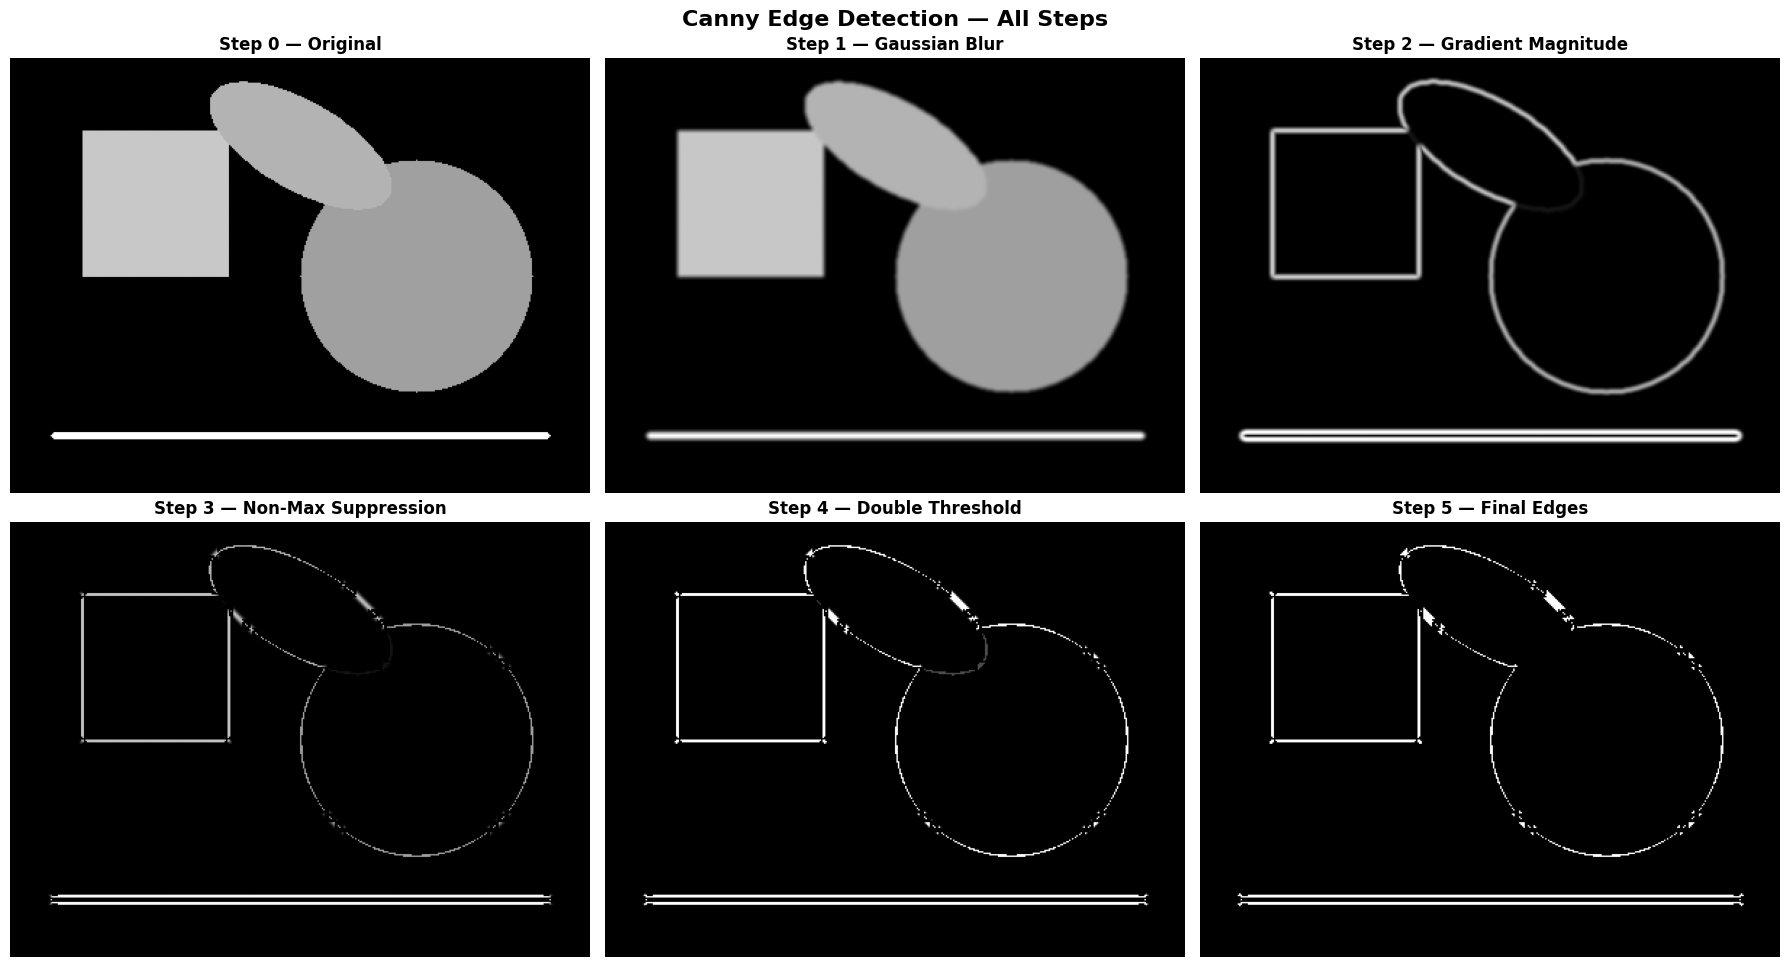

In [ ]:
# ── Display All Steps Together ──

gray_original = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

DisplayImage({
    'Step 0 — Original':          gray_original,
    'Step 1 — Gaussian Blur':     blurred,
    'Step 2 — Gradient Magnitude': magnitude,
    'Step 3 — Non-Max Suppression': suppressed,
    'Step 4 — Double Threshold':  thresholded,
    'Step 5 — Final Edges':       edges,
}, main_title='Canny Edge Detection — All Steps')

## 🔍 Compare: Our Result vs OpenCV Built-in

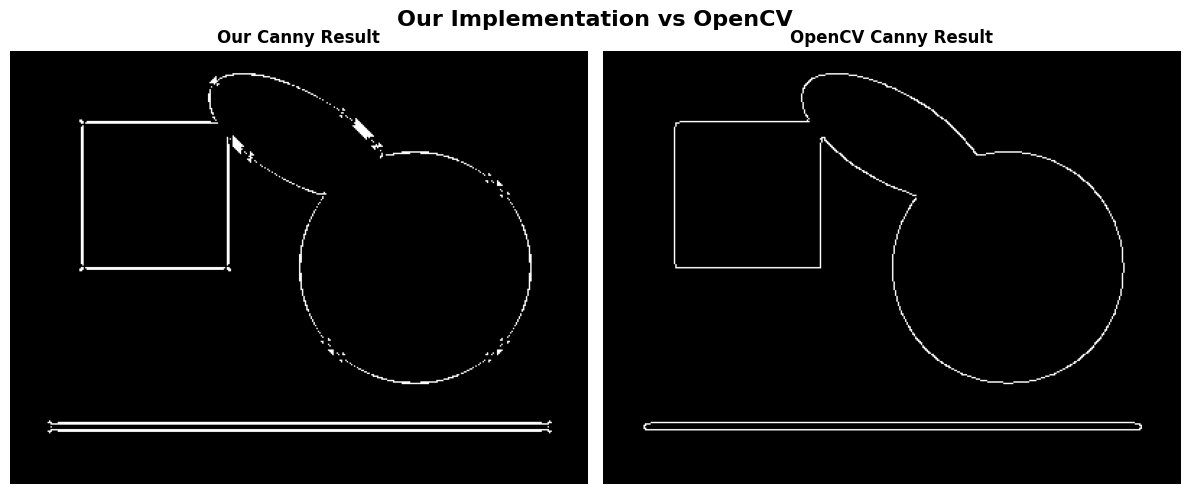

In [ ]:
# OpenCV's built-in Canny for comparison
opencv_edges = cv2.Canny(blurred, threshold1=30, threshold2=90)

DisplayImage({
    'Our Canny Result':    edges,
    'OpenCV Canny Result': opencv_edges,
}, main_title='Our Implementation vs OpenCV')